In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

In [4]:
mlr = joblib.load("../models/multiLinearReg.pkl")
rf = joblib.load("../models/randomForest.pkl")
gb = joblib.load("../models/gboost.pkl")
xgb = joblib.load("../models/xgboost.pkl")
ab = joblib.load("../models/adaboost.pkl")
cb = joblib.load("../models/catBoost.pkl")

X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

Performance Metric table

In [ ]:
models = {
    'multiLinearReg' : mlr,
    'randomForest' : rf,
    'gradientBoosting' : gb,
    'xtraGradientBoosting' : xgb,
    'adaboost' : ab,
    'catBoost' : cb
}

data = []# store all the evaluation metrics ->

for name,model in models.items():# traversing over the models dictionary ->
    c1 = []
    y_pred = model.predict(X_test)
    rmse = root_mean_squared_error(y_test,y_pred)
    mae = mean_absolute_error(y_test,y_pred)
    r2 = r2_score(y_test,y_pred)
    c1.append(name)
    c1.append(rmse)
    c1.append(mae)
    c1.append(r2)
    data.append(c1)

eval_table = pd.DataFrame(data,columns=['ModelName','RMSE','MAE','R2'])
eval_table

# sorting the evaluation table with respect to different performance metrics ->
eval_table = eval_table.sort_values(by=['RMSE'])
eval_table

,ModelName,RMSE,MAE,R2
1,randomForest,27.356120,22.731781,0.908359
2,gradientBoosting,27.983455,22.713162,0.904108
3,xtraGradientBoosting,29.051275,24.345467,0.896650
4,adaboost,31.014875,26.806882,0.882206
5,catBoost,31.360558,26.407601,0.879566
0,multiLinearReg,31.779200,25.080942,0.876329


Actual v/s Predicted values plot

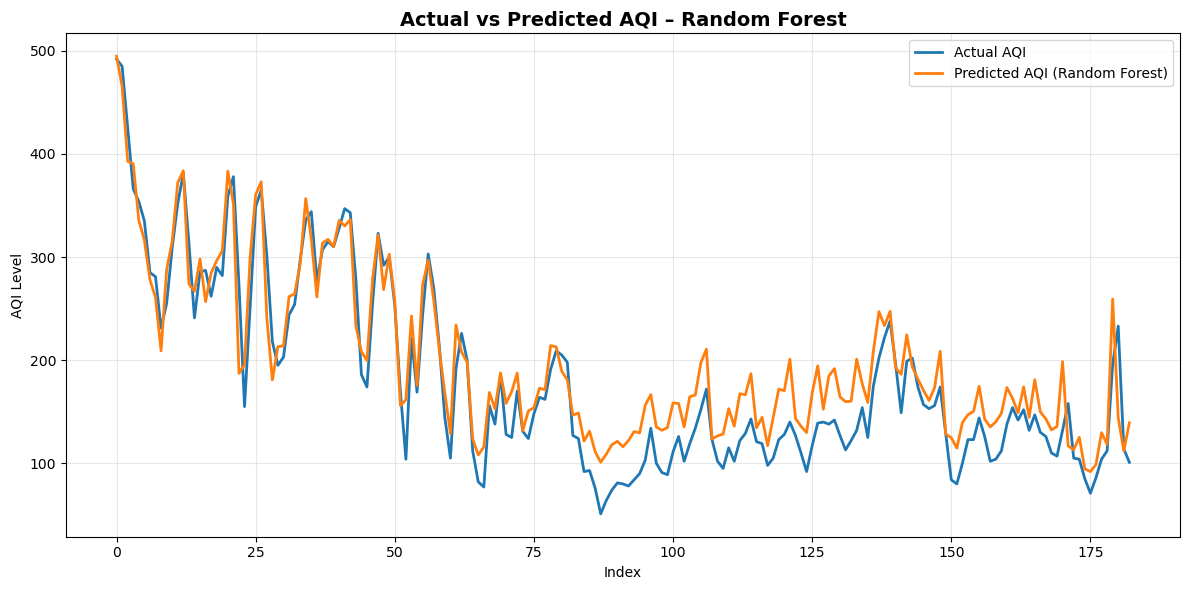

In [ ]:
# here, i am going to plot for the random forest regressor model -> rest can be replicated as same
plt.figure(figsize=(12,6))
y_pred = model.predict(X_test)
plt.plot(y_test, label='Actual AQI', linewidth=2)
plt.plot(y_pred, label='Predicted AQI (Random Forest)', linewidth=2)

plt.title("Actual vs Predicted AQI – Random Forest", fontsize=14, fontweight='bold')
plt.xlabel("Index")
plt.ylabel("AQI Level")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
